# Random Forest

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv('./Social_Network_Ads.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              400 non-null    int64
 1   EstimatedSalary  400 non-null    int64
 2   Purchased        400 non-null    int64
dtypes: int64(3)
memory usage: 9.5 KB


In [4]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [5]:
df.isnull().sum()

Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [6]:
X=df.iloc[:,:-1].values
y=df.iloc[:,-1].values

In [7]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [8]:
print(X_train)

[[    27  57000]
 [    46  28000]
 [    39 134000]
 [    44  39000]
 [    57  26000]
 [    32 120000]
 [    41  52000]
 [    48  74000]
 [    26  86000]
 [    22  81000]
 [    49  86000]
 [    36  54000]
 [    40  59000]
 [    41  80000]
 [    26  16000]
 [    39  79000]
 [    59 130000]
 [    42  64000]
 [    53 143000]
 [    34 112000]
 [    57 122000]
 [    39  71000]
 [    47  25000]
 [    24  19000]
 [    36  50000]
 [    32 150000]
 [    48  29000]
 [    30 107000]
 [    60  34000]
 [    38  61000]
 [    33  31000]
 [    39  71000]
 [    55  39000]
 [    49  39000]
 [    43 112000]
 [    27  20000]
 [    26  17000]
 [    37  93000]
 [    42  54000]
 [    35  61000]
 [    29  75000]
 [    38  80000]
 [    45  26000]
 [    54 108000]
 [    46  23000]
 [    23  28000]
 [    37  75000]
 [    42  65000]
 [    35  71000]
 [    51 146000]
 [    39  96000]
 [    24  89000]
 [    58  95000]
 [    25  22000]
 [    41  59000]
 [    28  89000]
 [    42  80000]
 [    42 108000]
 [    46  9600

In [9]:
print(y_train)

[0 1 1 0 1 1 0 1 0 0 1 0 0 0 0 0 1 0 1 1 1 0 1 0 0 1 1 1 1 0 0 0 1 1 1 0 0
 1 0 0 0 0 1 1 1 0 0 0 0 1 1 0 1 0 0 0 1 1 0 1 0 0 1 0 0 0 0 0 0 0 0 0 1 0
 0 0 1 0 1 0 1 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 1 0 0 1 1 0 0 0
 1 1 0 1 1 0 1 1 1 0 0 1 1 1 0 0 0 0 0 1 0 0 0 1 0 0 1 1 1 1 0 1 0 0 0 0 1
 0 1 0 0 0 1 0 0 0 1 1 1 1 0 0 0 0 0 1 0 1 1 0 0 0 1 0 1 0 1 1 0 1 0 0 0 0
 0 1 1 1 0 0 1 0 0 0 0 0 1 0 1 0 0 1 0 1 0 0 0 0 1 0 0 0 0 0 1 1 0 1 0 0 0
 1 0 0 0 0 0 0 1 0 0 0 1 1 0 1 1 0 0 0 0 1 0 1 1 1 0 0 0 0 0 0 0 1 0 0 0 0
 0 0 0 0 0 1 0 0 1 0 0 1 0 1 0 1 1 0 0 1 0 1 0 0 0 0 1 0 0 0 1 1 1 1 1 1 1
 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0]


In [10]:
print(X_test)

[[    46  22000]
 [    59  88000]
 [    28  44000]
 [    48  96000]
 [    29  28000]
 [    30  62000]
 [    47 107000]
 [    29  83000]
 [    40  75000]
 [    42  65000]
 [    35  65000]
 [    53  34000]
 [    23  48000]
 [    20  23000]
 [    30  87000]
 [    35 108000]
 [    52  38000]
 [    46  74000]
 [    39  42000]
 [    56  60000]
 [    22  27000]
 [    29  80000]
 [    47  23000]
 [    59  76000]
 [    19  19000]
 [    51  23000]
 [    42  80000]
 [    37  53000]
 [    55 125000]
 [    19  21000]
 [    46  41000]
 [    19  70000]
 [    36 144000]
 [    28  79000]
 [    40 107000]
 [    35  75000]
 [    37  55000]
 [    38  65000]
 [    26  30000]
 [    18  68000]
 [    48  33000]
 [    24  55000]
 [    18  52000]
 [    47  20000]
 [    20  49000]
 [    44 139000]
 [    29  61000]
 [    31  71000]
 [    48  41000]
 [    34  43000]
 [    25  79000]
 [    53  82000]
 [    38  55000]
 [    25  80000]
 [    37  80000]
 [    27  31000]
 [    60 102000]
 [    26 118000]
 [    31  7400

In [11]:
print(y_test)

[0 1 0 1 0 0 1 0 0 0 0 1 0 0 0 0 1 0 0 1 0 0 1 1 0 1 0 0 1 0 1 0 1 0 1 0 0
 0 0 0 1 0 0 1 0 1 0 0 1 0 0 1 0 0 0 0 1 0 0 0 0 0 1 0 0 1 1 1 0 0 1 0 0 0
 1 0 1 1 0 1]


In [12]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.fit_transform(X_test)

In [13]:
print(X_train)

[[-1.06675246 -0.38634438]
 [ 0.79753468 -1.22993871]
 [ 0.11069205  1.853544  ]
 [ 0.60129393 -0.90995465]
 [ 1.87685881 -1.28811763]
 [-0.57615058  1.44629156]
 [ 0.3069328  -0.53179168]
 [ 0.99377543  0.10817643]
 [-1.16487283  0.45724994]
 [-1.55735433  0.31180264]
 [ 1.0918958   0.45724994]
 [-0.18366908 -0.47361276]
 [ 0.20881242 -0.32816546]
 [ 0.3069328   0.28271318]
 [-1.16487283 -1.57901222]
 [ 0.11069205  0.25362372]
 [ 2.07309956  1.73718616]
 [ 0.40505317 -0.18271817]
 [ 1.4843773   2.11534913]
 [-0.37990983  1.21357589]
 [ 1.87685881  1.50447048]
 [ 0.11069205  0.02090805]
 [ 0.89565505 -1.31720709]
 [-1.36111358 -1.49174384]
 [-0.18366908 -0.5899706 ]
 [-0.57615058  2.31897535]
 [ 0.99377543 -1.20084925]
 [-0.77239133  1.06812859]
 [ 2.17121993 -1.05540195]
 [ 0.01257167 -0.26998655]
 [-0.4780302  -1.14267033]
 [ 0.11069205  0.02090805]
 [ 1.68061805 -0.90995465]
 [ 1.0918958  -0.90995465]
 [ 0.50317355  1.21357589]
 [-1.06675246 -1.46265438]
 [-1.16487283 -1.54992276]
 

In [14]:
print(X_test)

[[ 0.80285749 -1.39649711]
 [ 1.93579072  0.62530293]
 [-0.76581929 -0.72256376]
 [ 0.97715491  0.8703696 ]
 [-0.67867058 -1.21269711]
 [-0.59152187 -0.17116375]
 [ 0.8900062   1.20733627]
 [-0.67867058  0.47213626]
 [ 0.27996523  0.22706959]
 [ 0.45426265 -0.07926375]
 [-0.15577832 -0.07926375]
 [ 1.41289846 -1.0288971 ]
 [-1.20156284 -0.60003043]
 [-1.46300897 -1.36586378]
 [-0.59152187  0.5946696 ]
 [-0.15577832  1.23796961]
 [ 1.32574975 -0.90636377]
 [ 0.80285749  0.19643625]
 [ 0.19281652 -0.78383043]
 [ 1.67434459 -0.23243042]
 [-1.28871155 -1.24333044]
 [-0.67867058  0.38023626]
 [ 0.8900062  -1.36586378]
 [ 1.93579072  0.25770292]
 [-1.55015768 -1.48839711]
 [ 1.23860104 -1.36586378]
 [ 0.45426265  0.38023626]
 [ 0.0185191  -0.44686376]
 [ 1.58719588  1.75873629]
 [-1.55015768 -1.42713045]
 [ 0.80285749 -0.81446377]
 [-1.55015768  0.07390292]
 [-0.06862961  2.34076963]
 [-0.76581929  0.34960292]
 [ 0.27996523  1.20733627]
 [-0.15577832  0.22706959]
 [ 0.0185191  -0.38559709]
 

In [15]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier(
    criterion='entropy',
    n_estimators=10
)
model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",10
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metr

In [18]:
y_pred = model.predict(X_test)
print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test.reshape(len(y_test),1)),1))

[[1 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 0]
 [1 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 1]
 [0 0]
 [1 1]
 [1 0]
 [0 0]
 [1 1]
 [0 0]
 [0 1]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 1]
 [0 0]
 [0 0]
 [0 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [1 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [1 0]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [1 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 1]]


In [19]:
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_test, y_pred)
print(cm)
accuracy_score(y_test, y_pred)

[[45  7]
 [ 6 22]]


0.8375

C:\Users\Dell\AppData\Local\Temp\ipykernel_14736\3278020845.py:10: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)


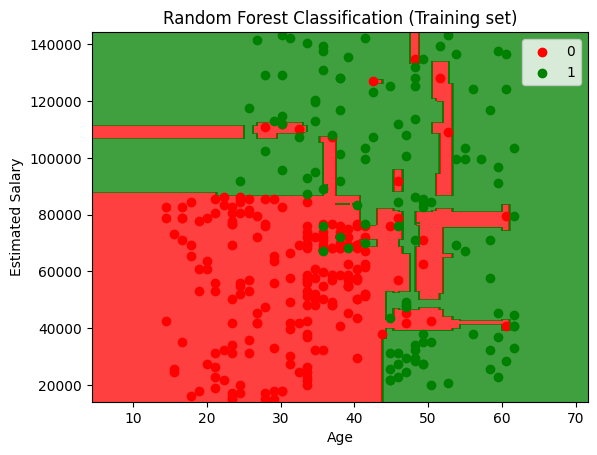

In [20]:
from matplotlib.colors import ListedColormap
X_set, y_set = sc.inverse_transform(X_train), y_train
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = 0.25),
                     np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 0.25))
plt.contourf(X1, X2, model.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('Random Forest Classification (Training set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()

C:\Users\Dell\AppData\Local\Temp\ipykernel_14736\1575857159.py:10: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)


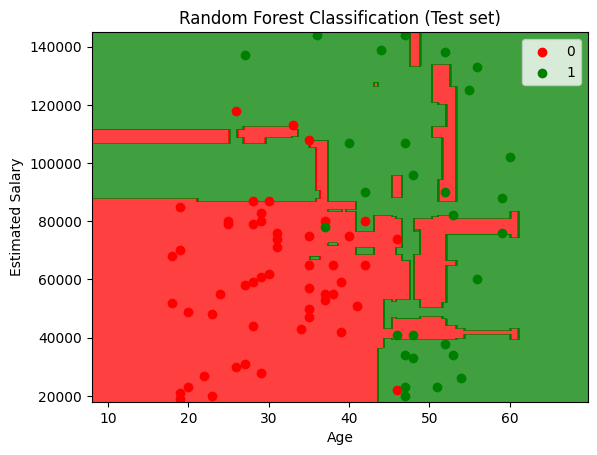

In [21]:
from matplotlib.colors import ListedColormap
X_set, y_set = sc.inverse_transform(X_test), y_test
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = 0.25),
                     np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 0.25))
plt.contourf(X1, X2, model.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('Random Forest Classification (Test set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()